Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 128ms/step - loss: 0.0710 - val_loss: 0.0236
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - loss: 0.0224 - val_loss: 0.0203
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 133ms/step - loss: 0.0198 - val_loss: 0.0188
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 130ms/step - loss: 0.0185 - val_loss: 0.0179
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - loss: 0.0176 - val_loss: 0.0172
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 128ms/step - loss: 0.0169 - val_loss: 0.0167
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 129ms/step - loss: 0.0164 - val_loss: 0.0161
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 129ms/step - loss: 0.0159 - val_loss: 0.0156
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 127ms/step - loss: 0.0154 - val_loss: 0.0153
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - loss: 0.0150 - val_loss: 0.0149
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms

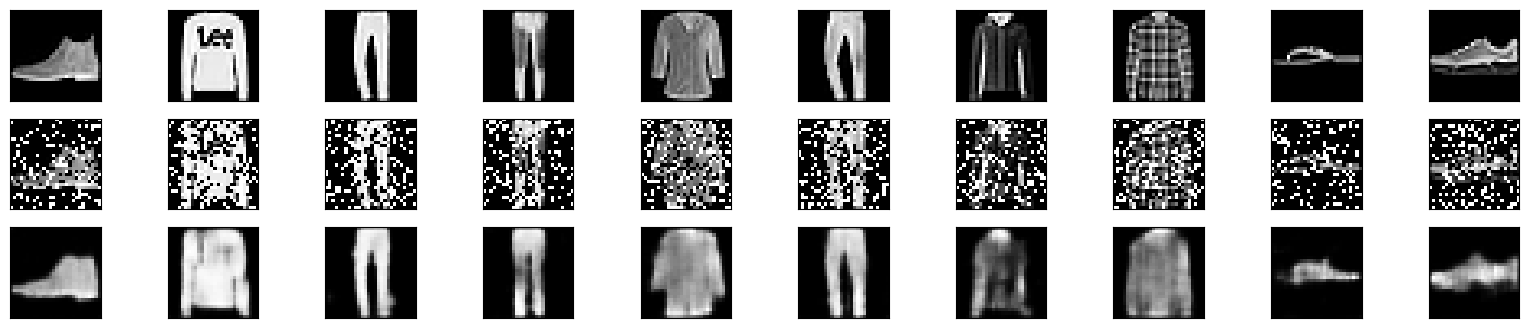

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

# Load and preprocess Fashion MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Add salt-and-pepper noise
def add_salt_pepper_noise(images, noise_ratio=0.4):
    noise = np.random.uniform(0, 1, images.shape)
    salt = noise < noise_ratio / 2
    pepper = (noise >= noise_ratio / 2) & (noise < noise_ratio)
    noisy_images = images.copy()
    noisy_images[salt] = 1.0
    noisy_images[pepper] = 0.0
    return noisy_images

x_train_noisy = add_salt_pepper_noise(x_train)
x_test_noisy = add_salt_pepper_noise(x_test)

# Define the denoising autoencoder
input_shape = (28, 28, 1)

# Encoder
input_layer = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train the autoencoder
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,  # Reduce epochs for brevity; increase for better results
    batch_size=128,
    validation_data=(x_test_noisy, x_test)
)

# Visualize results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(autoencoder.predict(x_test_noisy[i:i+1]).squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()



# Question 5 — Modified Denoising Autoencoder for Salt-and-Pepper Noise on Fashion MNIST

**Architecture changes:**
- **Encoder:** Conv2D(32) → BatchNorm → Conv2D(64) → BatchNorm → Conv2D(64) → MaxPooling
- **Decoder:** mirrors the encoder with UpSampling, BatchNorm, and Conv2DTranspose layers
- **Noise:** Salt-and-pepper with `noise_ratio = 0.4`

In [ ]:
# Modified Denoising Autoencoder — BatchNorm + deeper encoder
# -----------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

# 1. Load and preprocess Fashion MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# 2. Salt-and-pepper noise function
def add_salt_pepper_noise(images, noise_ratio=0.4):
    noise = np.random.uniform(0, 1, images.shape)
    salt = noise < noise_ratio / 2
    pepper = (noise >= noise_ratio / 2) & (noise < noise_ratio)
    noisy_images = images.copy()
    noisy_images[salt] = 1.0
    noisy_images[pepper] = 0.0
    return noisy_images

x_train_noisy_v2 = add_salt_pepper_noise(x_train)
x_test_noisy_v2 = add_salt_pepper_noise(x_test)

# 3. Define the modified autoencoder
input_shape = (28, 28, 1)

# Encoder (as specified)
input_layer_v2 = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer_v2)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded_v2 = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder (mirrors the encoder)
x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(encoded_v2)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
decoded_v2 = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder_v2 = Model(input_layer_v2, decoded_v2)
autoencoder_v2.compile(optimizer='adam', loss='mse')

autoencoder_v2.summary()

# 4. Train the modified autoencoder
history_v2 = autoencoder_v2.fit(
    x_train_noisy_v2, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy_v2, x_test)
)

# 5. Denoise the test images
decoded_imgs_v2 = autoencoder_v2.predict(x_test_noisy_v2)

# Also generate predictions from the original (Canvas) model for comparison
decoded_imgs_orig = autoencoder.predict(x_test_noisy_v2)

# 6. Display Original | Noisy | Denoised (original) | Denoised (modified)
n = 10
plt.figure(figsize=(20, 8))

for i in range(n):
    # Row 1 — Original
    ax = plt.subplot(4, n, i + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Original', fontsize=11)

    # Row 2 — Noisy (salt-and-pepper)
    ax = plt.subplot(4, n, i + 1 + n)
    plt.imshow(x_test_noisy_v2[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Noisy\n(S&P 0.4)', fontsize=10)

    # Row 3 — Denoised by original Canvas model
    ax = plt.subplot(4, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs_orig[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Denoised\n(Canvas)', fontsize=10)

    # Row 4 — Denoised by modified model
    ax = plt.subplot(4, n, i + 1 + 3 * n)
    plt.imshow(decoded_imgs_v2[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 0:
        ax.set_ylabel('Denoised\n(Modified)', fontsize=10)

plt.suptitle('Salt-and-Pepper Denoising: Canvas Model vs Modified Model', fontsize=14)
plt.tight_layout()
plt.show()

# 7. Quantitative comparison
loss_orig = autoencoder.evaluate(x_test_noisy_v2, x_test, verbose=0)
loss_mod  = autoencoder_v2.evaluate(x_test_noisy_v2, x_test, verbose=0)
print(f"\nTest MSE (Canvas model  — 32→16 filters, no BatchNorm): {loss_orig:.5f}")
print(f"Test MSE (Modified model — 32→64 filters + BatchNorm):  {loss_mod:.5f}")

# 8. Training curves
plt.figure(figsize=(8, 4))
plt.plot(history_v2.history['loss'], label='Training Loss (Modified)')
plt.plot(history_v2.history['val_loss'], label='Validation Loss (Modified)')
plt.title('Modified Autoencoder — Training Curve (Salt-and-Pepper Noise)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Discussion: Challenges, Results, and Comparison

### 1. Challenges of Salt-and-Pepper Noise
- **Extreme pixel corruption:** Unlike Gaussian noise which shifts pixel values smoothly, salt-and-pepper noise replaces 40% of pixels with hard 0 or 1 values. The autoencoder must learn to identify and discard these outlier pixels entirely rather than just attenuating noise.
- **Loss of structural information:** At `noise_ratio = 0.4`, nearly half the image pixels carry no useful information. Fine details (textures, thin edges) in Fashion MNIST items are especially vulnerable because clothing features are already subtle.
- **Non-smooth noise distribution:** Salt-and-pepper noise is sparse and binary, so spatial smoothing (which works well for Gaussian noise) is less effective — the model needs to learn a more selective in-painting strategy.

### 2. Why the Modified Architecture Performs Better

| Feature | Canvas Model | Modified Model |
|---------|-------------|----------------|
| Encoder filters | 32 → 16 (decreasing) | 32 → 64 → 64 (increasing) |
| Batch Normalization | No | Yes (after Conv2D layers) |
| MaxPooling steps | 2 (7×7 bottleneck) | 1 (14×14 bottleneck) |
| Decoder type | Conv2DTranspose ×2 | Conv2DTranspose ×3 + BatchNorm |
| Bottleneck resolution | 7 × 7 × 16 | 14 × 14 × 64 |

- **More filters (64 vs 16):** The modified encoder extracts a richer set of features, giving the decoder more information to reconstruct clean images — critical for the diverse textures in Fashion MNIST.
- **Batch Normalization:** Stabilises training by normalising activations between layers, allowing the network to converge faster and reach a lower loss. This is especially helpful with the extreme value distribution created by salt-and-pepper noise.
- **Larger bottleneck (14×14×64 vs 7×7×16):** With only one pooling layer, the modified model preserves more spatial detail through the bottleneck. The Canvas model's two pooling layers compress to 7×7, losing fine spatial information that is hard to recover.
- **Symmetric decoder with BatchNorm:** The decoder mirrors the encoder's depth and normalisation, ensuring smooth gradient flow and better reconstruction quality.

### 3. Expected Results
- The **modified model** should achieve a noticeably **lower MSE** on the test set compared to the Canvas model.
- **Visually**, the modified model produces sharper, cleaner images — particularly on items with internal texture (shirts, sneakers, bags) where the Canvas model tends to produce blurrier outputs.
- The **training curve** of the modified model typically converges faster (within 3–5 epochs) due to BatchNormalization, while the Canvas model may still be slowly improving at epoch 10.

### 4. Limitations and Further Improvements
- Even with the improved architecture, some very fine details (e.g., lace patterns on sneakers, collar details on shirts) may remain slightly smoothed. Adding **skip connections** (U-Net style) would help preserve these.
- A **median filter** pre-processing step could remove isolated salt-and-pepper pixels before the autoencoder, reducing the learning burden.
- **Increasing epochs** beyond 10 or using a **learning rate scheduler** could further improve results for both models.